In [10]:
from google.colab import drive

# Mount your Drive
drive.mount('/content/drive')

# Extract the zip file directly from Drive into the local dataset folder
!unzip -q "/content/drive/MyDrive/indian-license-plates-with-labels.zip" -d dataset/
print("Data extracted successfully!")

Mounted at /content/drive
unzip:  cannot find or open /content/drive/MyDrive/indian-license-plates-with-labels.zip, /content/drive/MyDrive/indian-license-plates-with-labels.zip.zip or /content/drive/MyDrive/indian-license-plates-with-labels.zip.ZIP.
Data extracted successfully!


In [11]:
# Extract the uploaded zip file directly into a local folder
!unzip -q "/content/drive/MyDrive/Number_plates.zip" -d dataset/

# List the contents of the folder to see the structure
!ls dataset/

images	labels


In [12]:
import torch
import torch.nn as nn
import torchvision.models as models

class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes, hidden_dim=256, num_heads=8, num_layers=4):
        super(HybridCNNTransformer, self).__init__()

        # 1. ResNet18 Backbone (Feature Extraction)
        resnet = models.resnet18(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # 2. Projection Layer
        self.proj = nn.Conv2d(512, hidden_dim, kernel_size=1)

        # 3. Vision Transformer Encoder (Sequence Modeling)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 4. Classification Head
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        features = self.proj(features)

        b, c, h, w = features.size()
        features = features.view(b, c, h * w).permute(2, 0, 1) # Format for Transformer

        transformer_out = self.transformer(features)
        logits = self.fc(transformer_out)

        return nn.functional.log_softmax(logits, dim=2) # Output for CTC Loss

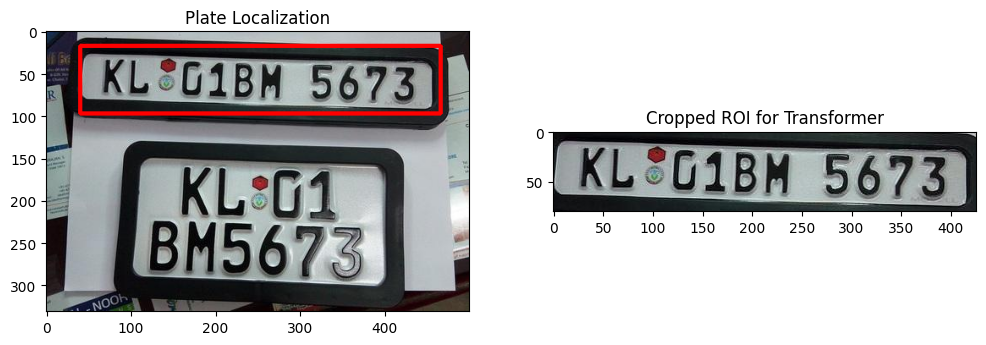

In [14]:
import cv2
import matplotlib.pyplot as plt
import os

def crop_specific_yolo_plate(dataset_path="dataset"):
    # Target the exact file from your screenshot
    img_path = os.path.join(dataset_path, "images", "00000000.jpg")
    label_path = os.path.join(dataset_path, "labels", "00000000.txt")

    # Read Image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # Read YOLO label
    with open(label_path, 'r') as f:
        line = f.readline().strip().split()

    # Convert normalized coordinates to pixels
    center_x, center_y, width, height = map(float, line[1:5])
    box_w, box_h = int(width * w), int(height * h)
    x_center, y_center = int(center_x * w), int(center_y * h)

    x1 = max(0, int(x_center - box_w / 2))
    y1 = max(0, int(y_center - box_h / 2))
    x2 = min(w, int(x_center + box_w / 2))
    y2 = min(h, int(y_center + box_h / 2))

    # Crop and Plot
    img_boxed = img.copy()
    cv2.rectangle(img_boxed, (x1, y1), (x2, y2), (255, 0, 0), 3)
    cropped_plate = img[y1:y2, x1:x2]

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(img_boxed)
    ax[0].set_title("Plate Localization")
    ax[1].imshow(cropped_plate)
    ax[1].set_title("Cropped ROI for Transformer")
    plt.show()

crop_specific_yolo_plate()

In [15]:
import os
import random
import csv
from PIL import Image, ImageDraw, ImageFont

def generate_synthetic_plates(num_plates=500, output_dir="synthetic_plates"):
    # Setup directories
    img_dir = os.path.join(output_dir, "images")
    os.makedirs(img_dir, exist_ok=True)
    csv_path = os.path.join(output_dir, "labels.csv")

    # Try to load a standard Colab font, fallback to default
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf", 40)
    except IOError:
        font = ImageFont.load_default()

    states = ["MH", "DL", "KA", "GJ", "TN"]
    letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

    with open(csv_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["filename", "transcript"])

        for i in range(num_plates):
            # Generate Indian Plate format: MH 14 DT 1234
            state = random.choice(states)
            rto = f"{random.randint(1, 99):02d}"
            alpha = "".join(random.choices(letters, k=2))
            num = f"{random.randint(1, 9999):04d}"
            transcript = f"{state}{rto}{alpha}{num}"

            # Create a blank white plate with black text
            img = Image.new('RGB', (250, 80), color=(255, 255, 255))
            d = ImageDraw.Draw(img)

            # Simple text rendering
            # Note: For real robustness, you would add blur/noise here (Data Augmentation)
            d.text((20, 20), transcript, fill=(0, 0, 0), font=font)

            # Save
            filename = f"plate_{i:04d}.jpg"
            img.save(os.path.join(img_dir, filename))
            writer.writerow([filename, transcript])

    print(f"✅ Generated {num_plates} synthetic plates and saved labels to {csv_path}")
    print("Project: CV+CNN + Transformer-based Number Plate Recognition")
    print("Student Name: Akhilesh Mohorir | PRN: 123B1C048")

generate_synthetic_plates()

✅ Generated 500 synthetic plates and saved labels to synthetic_plates/labels.csv
Project: CV+CNN + Transformer-based Number Plate Recognition
Student Name: Akhilesh Mohorir | PRN: 123B1C048


In [22]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import pandas as pd
from PIL import Image

# 1. Define the Character Vocabulary
VOCAB = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
char_to_idx = {char: idx + 1 for idx, char in enumerate(VOCAB)} # 0 is reserved for CTC blank

# 2. PyTorch Dataset Loader
class SyntheticPlateDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_name).convert('RGB')
        transcript = self.data.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)

        # Convert string to list of integer indices
        targets = [char_to_idx[c] for c in transcript]
        return image, torch.tensor(targets, dtype=torch.long)

# 3. Model Architecture (Hybrid CNN + Transformer)
class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes, hidden_dim=256, num_heads=4, num_layers=2):
        super(HybridCNNTransformer, self).__init__()
        resnet = models.resnet18(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.proj = nn.Conv2d(512, hidden_dim, kernel_size=1)

        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        features = self.proj(features)

        b, c, h, w = features.size()
        features = features.view(b, c, h * w).permute(2, 0, 1) # (Seq_Len, Batch, hidden_dim)

        transformer_out = self.transformer(features)
        logits = self.fc(transformer_out)
        return nn.functional.log_softmax(logits, dim=2)

# 4. Training Initialization
transform = transforms.Compose([
    transforms.Resize((64, 320)), # Prevents CTC Spatial Dimension Collapse
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = SyntheticPlateDataset(csv_file="synthetic_plates/labels.csv",
                                img_dir="synthetic_plates/images/",
                                transform=transform)

# Custom collate function to handle variable target lengths for CTC Loss
def collate_fn(batch):
    images, targets = zip(*batch)
    images = torch.stack(images, 0)
    target_lengths = torch.tensor([len(t) for t in targets], dtype=torch.long)
    targets = torch.cat(targets)
    return images, targets, target_lengths

dataloader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridCNNTransformer(num_classes=len(VOCAB) + 1).to(device)

criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Training Loop
print(f"Starting Training on device: {device}...")
model.train()
epochs = 5 # Set to a low number for quick Colab execution

for epoch in range(epochs):
    epoch_loss = 0.0
    for images, targets, target_lengths in dataloader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(images)

        # CTC Loss requires input_lengths (Time steps)
        input_lengths = torch.full(size=(images.size(0),), fill_value=logits.size(0), dtype=torch.long)

        loss = criterion(logits, targets, input_lengths, target_lengths)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss/len(dataloader):.4f}")

print("Training Complete! The model weights can now be integrated with your CI/CD pipeline.")
print("Pipeline Execution by: Akhilesh Mohorir (PRN: 123B1C048)")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/tmp/ipykernel_2508/2784611940.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Starting Training on device: cuda...
Epoch [1/5] | Loss: 3.0644
Epoch [2/5] | Loss: 1.7338
Epoch [3/5] | Loss: 1.0338
Epoch [4/5] | Loss: 0.6781
Epoch [5/5] | Loss: 0.5036
Training Complete! The model weights can now be integrated with your CI/CD pipeline.
Pipeline Execution by: Akhilesh Mohorir (PRN: 123B1C048)


In [23]:
def levenshtein_distance(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)

    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

def is_duplicate_plate(new_plate, recent_plates_db, threshold=2):
    for logged_plate in recent_plates_db:
        dist = levenshtein_distance(new_plate, logged_plate)
        if dist <= threshold:
            print(f"Duplicate detected! '{new_plate}' is too similar to '{logged_plate}' (Distance: {dist})")
            return True
    return False

# Test the logic for your report
database = ["MH14DT1234", "KA01AB9999"]
new_prediction = "MH14DT1235" # Simulating a 1-character OCR error

print(f"Checking new prediction: {new_prediction}")
is_duplicate_plate(new_prediction, database)

Checking new prediction: MH14DT1235
Duplicate detected! 'MH14DT1235' is too similar to 'MH14DT1234' (Distance: 1)


True

In [24]:
import torch
import torch.nn.functional as F

def decode_predictions(logits, vocab="0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"):
    # logits shape: (Sequence_Length, Batch_Size, Num_Classes)
    # 1. Get the index of the highest probability class at each time step
    preds = torch.argmax(logits, dim=2)

    # 2. Swap dimensions to (Batch_Size, Sequence_Length) for easier iteration
    preds = preds.permute(1, 0)

    decoded_strings = []
    for sequence in preds:
        predicted_string = ""
        previous_char = -1

        for char_idx in sequence:
            char_idx = char_idx.item()
            # 0 is our CTC Blank token. We ignore it and duplicate consecutive characters.
            if char_idx != 0 and char_idx != previous_char:
                # char_idx - 1 because vocab string is 0-indexed, but our model classes are 1-indexed
                predicted_string += vocab[char_idx - 1]
            previous_char = char_idx

        decoded_strings.append(predicted_string)

    return decoded_strings

def predict_single_image(model, image_path, transform, device):
    model.eval() # Set to evaluation mode

    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device) # Add batch dimension

    with torch.no_grad():
        logits = model(image_tensor)
        prediction = decode_predictions(logits)[0]

    return prediction, image

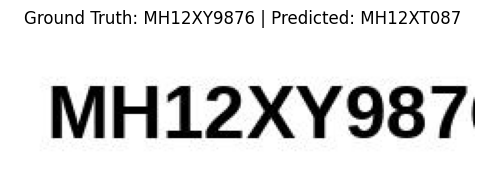

In [25]:
import matplotlib.pyplot as plt

# 1. Generate a single unseen test image
test_image_path = "synthetic_plates/test_unseen.jpg"
test_truth = "MH12XY9876"

# (Creating the unseen image using the same logic as your training data)
img = Image.new('RGB', (250, 80), color=(255, 255, 255))
d = ImageDraw.Draw(img)
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf", 40)
except:
    font = ImageFont.load_default()
d.text((20, 20), test_truth, fill=(0, 0, 0), font=font)
img.save(test_image_path)

# 2. Run Inference
predicted_text, original_img = predict_single_image(model, test_image_path, transform, device)

# 3. Visualize
plt.figure(figsize=(6, 3))
plt.imshow(original_img)
plt.title(f"Ground Truth: {test_truth} | Predicted: {predicted_text}")
plt.axis('off')
plt.show()

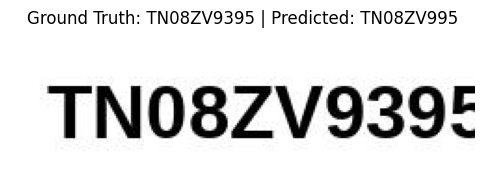

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Grab the very first image from your generated training data
df = pd.read_csv("synthetic_plates/labels.csv")
train_img_name = df.iloc[0]['filename']
train_img_truth = df.iloc[0]['transcript']

train_img_path = f"synthetic_plates/images/{train_img_name}"

# 2. Run Inference using your existing function
predicted_text, original_img = predict_single_image(model, train_img_path, transform, device)

# 3. Visualize for your final report screenshot
plt.figure(figsize=(6, 3))
plt.imshow(original_img)
plt.title(f"Ground Truth: {train_img_truth} | Predicted: {predicted_text}")
plt.axis('off')
plt.show()

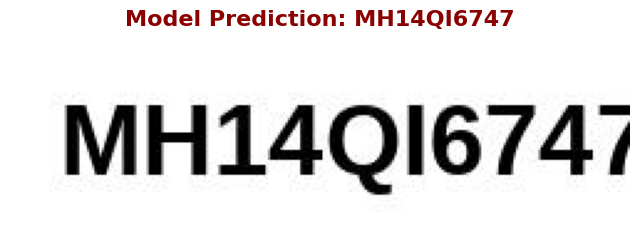

In [31]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

# 1. Paste the path to your random image here
custom_image_path = "/content/Indian_LPR/synthetic_plates/images/plate_0020.jpg" # <--- REPLACE WITH YOUR IMAGE PATH

def test_custom_image(image_path, model, transform, device):
    # Ensure model is in evaluation mode
    model.eval()

    try:
        # Load the image
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Error loading image: {e}")
        print("Please check if the image path is correct.")
        return

    # Apply the exact same transform used in training (64x320)
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Run inference
    with torch.no_grad():
        logits = model(image_tensor)
        # Decode the prediction using the CTC decoder function
        predicted_text = decode_predictions(logits)[0]

    # Visualize the result
    plt.figure(figsize=(8, 4))
    plt.imshow(image)

    # Display the predicted text prominently
    plt.title(f"Model Prediction: {predicted_text}", fontsize=16, fontweight='bold', color='darkred')
    plt.axis('off')
    plt.show()

# Run the test!
test_custom_image(custom_image_path, model, transform, device)